In [16]:
from aiwhatif_cf.config import DATA_DIR, MODELS_DIR

TRAINING_PATH = DATA_DIR / "eta.csv"
TRAINING_PATH.is_file()

TEST_PATH = DATA_DIR / "ete.csv"
TEST_PATH.is_file()

True

In [17]:
import pandas as pd

hl_df_train = pd.read_csv(TRAINING_PATH).drop(columns=["Unnamed: 0"], errors="ignore")
hl_df_test = pd.read_csv(TEST_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

In [18]:
from sklearn.model_selection import train_test_split

X_train = hl_df_train.drop("hltprhc", axis=1)
y_train = hl_df_train["hltprhc"]

X_test = hl_df_test.drop("hltprhc", axis=1)
y_test = hl_df_test["hltprhc"]

print(X_train.shape)
print(X_test.shape)

(32883, 8)
(8221, 8)


In [19]:
from sklearn.preprocessing import MinMaxScaler
import joblib

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)



In [ ]:
import tensorflow as tf
from aiwhatif_cf.config import SystemConfig

def build_model(input_dim):
    inputs = tf.keras.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(64, activation="relu")(inputs)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(32, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs, outputs)
    model.compile(
        optimizer=tf.keras.optimizers.AdamW(1e-3, weight_decay=1e-4),
        loss="binary_crossentropy",
        metrics=[tf.keras.metrics.AUC(name="auc"), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()],
    )
    return model


config = SystemConfig(
    target="hltprhc",
    backend="TF2"
)
input_dim = len(config.feature_cols)
nn_classifier = build_model(input_dim)


E0000 00:00:1776247934.114190   24193 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776247934.114513   24272 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776247934.138504   24193 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [21]:
y_pred = nn_classifier.predict(X_test_scaled)
y_pred_labels = (y_pred > 0.5).astype(int)

257/257 ━━━━━━━━━━━━━━━━━━━━ 0s 460us/step


              precision    recall  f1-score   support

           0       0.90      0.36      0.52      7287
           1       0.12      0.69      0.21       934

    accuracy                           0.40      8221
   macro avg       0.51      0.53      0.36      8221
weighted avg       0.81      0.40      0.48      8221



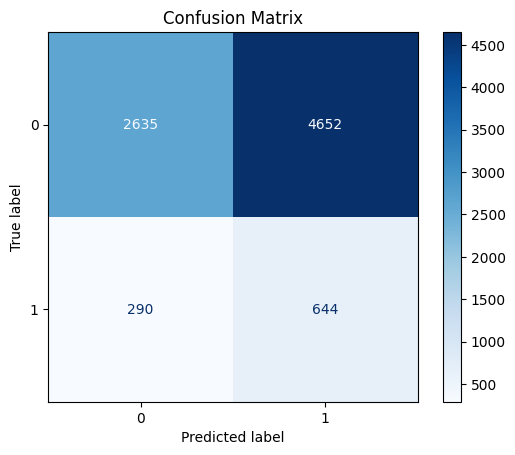

In [22]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


print(classification_report(y_test, y_pred_labels))

disp = ConfusionMatrixDisplay.from_predictions(y_test, y_pred_labels, cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


In [23]:
nn_classifier.save(MODELS_DIR / "nn_hltprhc.keras")
joblib.dump(scaler, MODELS_DIR / "scaler.pkl")

['/home/dyretna/Dokument/Code/GitHub/nightingale_projects/ai_counterfactuals_tests/models/scaler.pkl']